# Задание 13. Свёрточные нейронные сети (CNN) на MNIST

Что нужно сделать:
- Написать модель свёрточной нейронной сети для классификации изображений цифр (MNIST). Задача та же,
  что во второй части задания 10, но там она решалась полносвязной сетью — здесь будет свёрточная,
  и в конце сравним результаты.
- Рассмотреть две архитектуры:
  - **CNN 1**: `Input – conv – pool – conv – pool – полносвязная часть`;
  - **CNN 2**: `Input – conv – pool – conv – pool – conv – pool – полносвязная часть`.
- Параметры свёрточных слоёв: `padding = 1, stride = 1, kernel_size = 3`.
- Параметры pooling-слоёв: `padding = 0, stride = 2, kernel_size = 2`.
- Число каналов `n_channels` и тип pooling (Max / Average) назначить самостоятельно.
- Извлечь и визуализировать карту признаков (преобразованное представление исходной картинки)
  из промежуточного слоя сети.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

torch.manual_seed(42)
np.random.seed(42)

## Часть 1. Данные

Датасет тот же, что в задании 10: csv, где первый столбец — метка класса (цифра), а остальные 784 —
интенсивности пикселей картинки 28x28.

### Шаг 1. Загружаем MNIST

In [2]:
train_df = pd.read_csv("../mnist/mnist_train.csv")
test_df = pd.read_csv("../mnist/mnist_test.csv")

print("обучающая:", train_df.shape, " тестовая:", test_df.shape)
train_df.iloc[:5, :8]

обучающая: (60000, 785)  тестовая: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7
0,5,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0


Главное отличие от задания 10: полносвязной сети мы подавали строку из 784 чисел, а свёрточной нужна
картинка, поэтому пиксели надо вернуть в форму `(количество примеров, каналов, высота, ширина)`.
Канал один — картинки чёрно-белые. Как и раньше, делим на 255, чтобы значения были в диапазоне [0, 1].

In [3]:
X_train = train_df.drop("label", axis=1).values.astype(np.float32).reshape(-1, 1, 28, 28) / 255.0
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values.astype(np.float32).reshape(-1, 1, 28, 28) / 255.0
y_test = test_df["label"].values

Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train, dtype=torch.long)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test, dtype=torch.long)

print("обучающая:", Xtr.shape, " тестовая:", Xte.shape)
print("классы:", np.unique(y_train))

обучающая: torch.Size([60000, 1, 28, 28])  тестовая: torch.Size([10000, 1, 28, 28])
классы: [0 1 2 3 4 5 6 7 8 9]


### Шаг 2. Смотрим на картинки

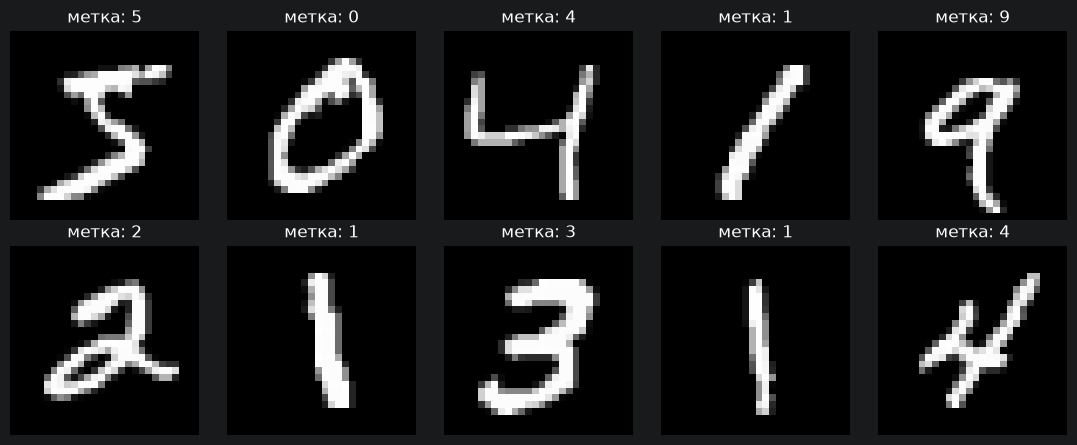

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))

for ax, i in zip(axes.flatten(), range(10)):
    ax.imshow(X_train[i, 0], cmap="gray")   # [i, 0] — первый (и единственный) канал
    ax.set_title("метка: " + str(y_train[i]))
    ax.axis("off")

plt.tight_layout()
plt.show()

Данные в порядке: после `reshape` картинки не «поехали», цифры читаются, метки им соответствуют.

## Часть 2. Свёрточные сети

### Шаг 3. Как меняется размер картинки внутри сети

Это самое неприятное место — надо аккуратно посчитать, сколько чисел придёт на вход первому `nn.Linear`.
С заданными параметрами свёртки (`kernel_size = 3, stride = 1, padding = 1`) размер картинки не меняется,
а pooling (`kernel_size = 2, stride = 2, padding = 0`) уменьшает его вдвое:

- **CNN 1**: 28 -> (conv) 28 -> (pool) 14 -> (conv) 14 -> (pool) 7. На выходе 16 каналов по 7x7,
  то есть на вход полносвязной части идёт 16 * 7 * 7 = 784 числа.
- **CNN 2**: добавляется ещё пара conv + pool: 7 -> (conv) 7 -> (pool) 3 (7 // 2 = 3, «лишняя» строка
  и столбец просто отбрасываются). На выходе 32 канала по 3x3, то есть 32 * 3 * 3 = 288 чисел.

Число каналов назначаю сам, без GridSearch: 8 -> 16 (-> 32), то есть при уменьшении картинки вдвое
число каналов удваивается — обычная схема. Полносвязная часть у обеих сетей одинаковая, чтобы сравнение
было честным: один скрытый слой из 64 нейронов и 10 выходных нейронов (по классу на цифру),
softmax считается внутри `nn.CrossEntropyLoss`.

### Шаг 4. Функция обучения

Цикл обучения тот же, что в задании 10: Adam с `lr = 0.001`, батчи по 64, после каждой эпохи считаем
ошибку и accuracy на тесте. Обучение свёрточной сети на процессоре идёт медленнее полносвязной
(около 5 секунд на эпоху против доли секунды), поэтому берём 8 эпох вместо 12 — по кривым видно,
что этого хватает. Выборку не урезаем, обучаем на всех 60000 примерах.

In [5]:
loss_fn = nn.CrossEntropyLoss()
batch = 64


def train(model, epochs=8):
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    train_loss, test_loss, test_acc = [], [], []

    for ep in range(epochs):
        idx = torch.randperm(len(Xtr))          # перемешиваем обучающую выборку
        running = 0.0
        for i in range(0, len(Xtr), batch):
            b = idx[i:i + batch]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()
            running += loss.item() * len(b)

        # после каждой эпохи смотрим, что получилось на тесте
        with torch.no_grad():
            out_te = model(Xte)
            train_loss.append(running / len(Xtr))
            test_loss.append(loss_fn(out_te, yte).item())
            test_acc.append((out_te.argmax(dim=1) == yte).float().mean().item())

        print(f"эпоха {ep + 1}: train loss = {train_loss[-1]:.4f}  "
              f"test loss = {test_loss[-1]:.4f}  test acc = {test_acc[-1]:.4f}")

    return train_loss, test_loss, test_acc

### Шаг 5. Выбираем тип pooling: Max или Average

Полноценный GridSearch по всем параметрам тут был бы слишком долгим, поэтому просто обучим
архитектуру 1 в двух вариантах по 3 эпохи и посмотрим, какой pooling лучше.

In [6]:
for pool_name, pool in [("MaxPool", nn.MaxPool2d), ("AvgPool", nn.AvgPool2d)]:
    print(pool_name + ":")
    torch.manual_seed(42)
    m = nn.Sequential(
        nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1), nn.ReLU(),
        pool(kernel_size=2, stride=2, padding=0),
        nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
        pool(kernel_size=2, stride=2, padding=0),
        nn.Flatten(),
        nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
        nn.Linear(64, 10),
    )
    train(m, epochs=3)
    print()

MaxPool:
эпоха 1: train loss = 0.3086  test loss = 0.1021  test acc = 0.9660
эпоха 2: train loss = 0.0937  test loss = 0.0615  test acc = 0.9802
эпоха 3: train loss = 0.0651  test loss = 0.0497  test acc = 0.9833

AvgPool:
эпоха 1: train loss = 0.3920  test loss = 0.1481  test acc = 0.9549
эпоха 2: train loss = 0.1294  test loss = 0.0891  test acc = 0.9733
эпоха 3: train loss = 0.0890  test loss = 0.0641  test acc = 0.9785



Max-pooling заметно лучше: после 3 эпох accuracy 0.9833 против 0.9785 и ошибка 0.0497 против 0.0641.
Логично: усреднение по окну 2x2 размывает штрих цифры, а максимум оставляет самый яркий отклик фильтра,
то есть «здесь такой признак есть». Дальше везде используем `nn.MaxPool2d`.

### Шаг 6. Архитектура 1: conv – pool – conv – pool – полносвязная часть

In [7]:
torch.manual_seed(42)

model1 = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
    nn.Linear(64, 10),
)

print(model1)
print("параметров:", sum(p.numel() for p in model1.parameters()))

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=784, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)
параметров: 52138


In [8]:
train_loss1, test_loss1, test_acc1 = train(model1)

эпоха 1: train loss = 0.3086  test loss = 0.1021  test acc = 0.9660
эпоха 2: train loss = 0.0937  test loss = 0.0615  test acc = 0.9802
эпоха 3: train loss = 0.0651  test loss = 0.0497  test acc = 0.9833
эпоха 4: train loss = 0.0521  test loss = 0.0408  test acc = 0.9870
эпоха 5: train loss = 0.0435  test loss = 0.0493  test acc = 0.9831
эпоха 6: train loss = 0.0368  test loss = 0.0417  test acc = 0.9861
эпоха 7: train loss = 0.0316  test loss = 0.0403  test acc = 0.9869
эпоха 8: train loss = 0.0276  test loss = 0.0371  test acc = 0.9885


### Шаг 7. Архитектура 2: conv – pool – conv – pool – conv – pool – полносвязная часть

In [9]:
torch.manual_seed(42)

model2 = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(32 * 3 * 3, 64), nn.ReLU(),
    nn.Linear(64, 10),
)

print(model2)
print("параметров:", sum(p.numel() for p in model2.parameters()))

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=288, out_features=64, bias=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)
параметров: 25034


Интересно, что у более глубокой сети параметров вышло в два раза меньше (25 тысяч против 52 тысяч):
третий pooling сжимает картинку до 3x3, и первый линейный слой получает 288 входов вместо 784.

In [10]:
train_loss2, test_loss2, test_acc2 = train(model2)

эпоха 1: train loss = 0.3652  test loss = 0.1068  test acc = 0.9676
эпоха 2: train loss = 0.0961  test loss = 0.0634  test acc = 0.9807
эпоха 3: train loss = 0.0714  test loss = 0.0589  test acc = 0.9806
эпоха 4: train loss = 0.0574  test loss = 0.0525  test acc = 0.9819
эпоха 5: train loss = 0.0476  test loss = 0.0378  test acc = 0.9880
эпоха 6: train loss = 0.0412  test loss = 0.0492  test acc = 0.9853
эпоха 7: train loss = 0.0352  test loss = 0.0425  test acc = 0.9867
эпоха 8: train loss = 0.0328  test loss = 0.0394  test acc = 0.9878


### Шаг 8. Кривые обучения

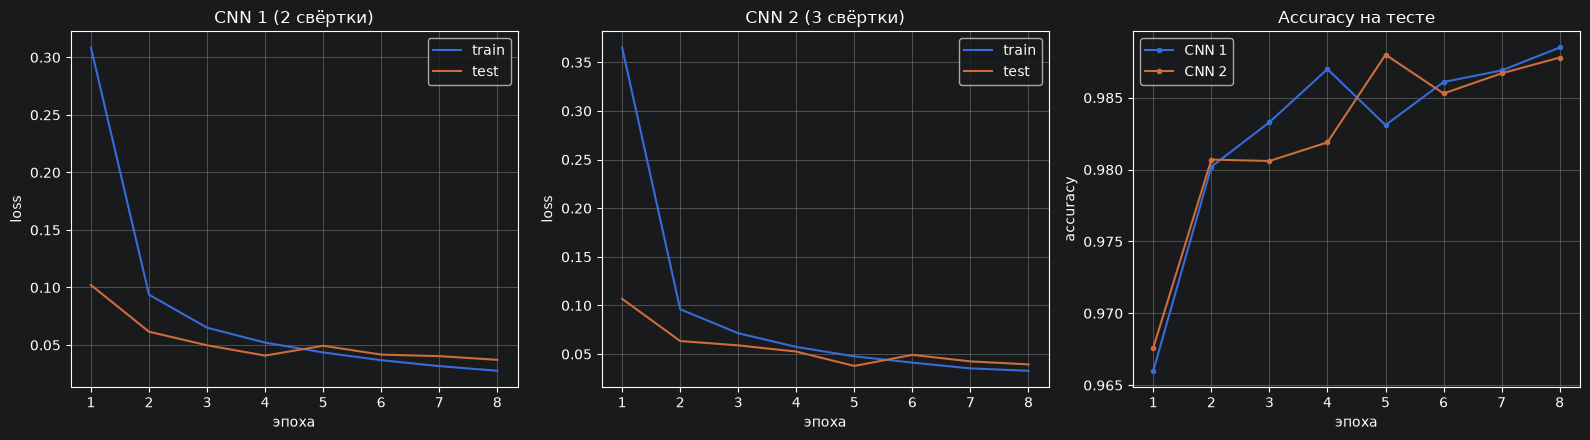

In [11]:
epochs = len(train_loss1)
ep_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(ep_range, train_loss1, label="train")
axes[0].plot(ep_range, test_loss1, label="test")
axes[0].set_title("CNN 1 (2 свёртки)")
axes[0].set_ylabel("loss")

axes[1].plot(ep_range, train_loss2, label="train")
axes[1].plot(ep_range, test_loss2, label="test")
axes[1].set_title("CNN 2 (3 свёртки)")
axes[1].set_ylabel("loss")

axes[2].plot(ep_range, test_acc1, marker=".", label="CNN 1")
axes[2].plot(ep_range, test_acc2, marker=".", label="CNN 2")
axes[2].set_title("Accuracy на тесте")
axes[2].set_ylabel("accuracy")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Обе сети ведут себя одинаково: основное падение ошибки — на первых двух эпохах, дальше кривые
выходят на плато около 0.04. Кривая теста идёт ниже обучающей (train loss усреднён по эпохе, когда сеть
была ещё хуже) и вверх не разворачивается, так что явного переобучения за 8 эпох нет. Accuracy на тесте
у обеих сетей колеблется в районе 0.985-0.988, и по графику видно, что дальнейшие эпохи дали бы
уже сотые доли процента.

### Шаг 9. Метрики и сравнение архитектур

Задача многоклассовая, поэтому Precision, Recall и F1 считаем с усреднением `macro` — как в задании 10.
В таблицу для сравнения добавляю строку с результатом полносвязной сети 784 -> 128 -> 10 из задания 10.

In [12]:
with torch.no_grad():
    pred1 = model1(Xte).argmax(dim=1).numpy()
    pred2 = model2(Xte).argmax(dim=1).numpy()


def metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, average="macro"),
            recall_score(y_true, y_pred, average="macro"),
            f1_score(y_true, y_pred, average="macro")]


res = pd.DataFrame([metrics(y_test, pred1),
                    metrics(y_test, pred2),
                    [0.9787, 0.9786, 0.9785, 0.9785]],   # результат из задания 10
                   index=["CNN 1 (2 свёртки)", "CNN 2 (3 свёртки)",
                          "Задание 10 (полносвязная)"],
                   columns=["Accuracy", "Precision", "Recall", "F1"])
res.round(4)

,Accuracy,Precision,Recall,F1
CNN 1 (2 свёртки),0.9885,0.9886,0.9884,0.9885
CNN 2 (3 свёртки),0.9878,0.9875,0.9878,0.9876
Задание 10 (полносвязная),0.9787,0.9786,0.9785,0.9785


In [13]:
print("ошибок CNN 1:", (pred1 != y_test).sum(), "из", len(y_test))
print("ошибок CNN 2:", (pred2 != y_test).sum(), "из", len(y_test))
print("параметров: CNN 1 —", sum(p.numel() for p in model1.parameters()),
      " CNN 2 —", sum(p.numel() for p in model2.parameters()))

ошибок CNN 1: 115 из 10000
ошибок CNN 2: 122 из 10000
параметров: CNN 1 — 52138  CNN 2 — 25034


Обе свёрточные сети дают примерно одинаковое качество (Accuracy 0.9885 и 0.9878), разница между ними
в пределах случайности инициализации. Третья пара conv + pool не помогла: картинка 28x28 маленькая,
после третьего pooling от неё остаётся 3x3, и на таком разрешении сжимать дальше уже нечего.
Зато обе уверенно обходят полносвязную сеть из задания 10: 0.9885 против 0.9787, то есть число ошибок
упало со 213 до 115 — почти вдвое, и это при том, что у CNN 1 параметров в 2 раза меньше
(52 тысячи против 101 тысячи). Свёртка смотрит на пиксели не по отдельности, а окном 3x3, поэтому
видит локальную форму штриха, а не просто «яркость пикселя номер 348».

### Шаг 10. Матрица ошибок

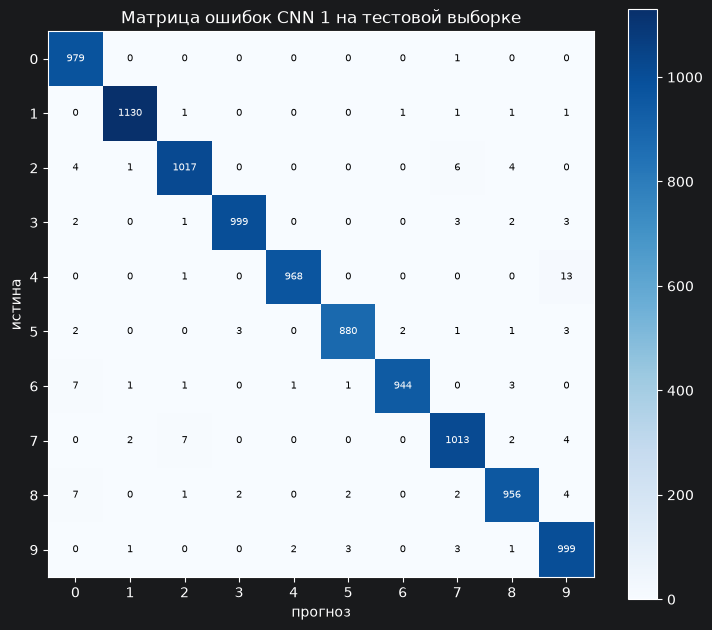

In [14]:
cm = confusion_matrix(y_test, pred1)

plt.figure(figsize=(7.5, 6.5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("прогноз")
plt.ylabel("истина")
plt.title("Матрица ошибок CNN 1 на тестовой выборке")
plt.tight_layout()
plt.show()

Ошибок почти не осталось: вне диагонали самое большое число — 13 (четвёрки, принятые за девятки).
В задании 10 путаницы 9/4, 7/2 и 5/3 были самыми частыми — у CNN они тоже остались, но стали
единичными; исчезли только «случайные» ошибки на нормально написанных цифрах.

## Часть 3. Карта признаков промежуточного слоя

Возьмём одну картинку из тестовой выборки и посмотрим, во что она превращается внутри сети.
Проще всего прогнать её по слоям `model1` вручную и сохранить выход каждого слоя — сразу видно,
как меняются размер и число каналов.

### Шаг 11. Прогоняем одну картинку по слоям

In [15]:
img = Xte[0:1]          # одна картинка, но форма (1, 1, 28, 28) — сети нужен батч
print("истинная метка:", y_test[0])

outs = []
out = img
with torch.no_grad():
    for layer in model1:
        out = layer(out)
        outs.append(out)
        print(layer.__class__.__name__.ljust(10), "->", tuple(out.shape))

истинная метка: 7
Conv2d     -> (1, 8, 28, 28)
ReLU       -> (1, 8, 28, 28)
MaxPool2d  -> (1, 8, 14, 14)
Conv2d     -> (1, 16, 14, 14)
ReLU       -> (1, 16, 14, 14)
MaxPool2d  -> (1, 16, 7, 7)
Flatten    -> (1, 784)
Linear     -> (1, 64)
ReLU       -> (1, 64)
Linear     -> (1, 10)


Размеры совпадают с посчитанными в шаге 3: 28x28 -> 14x14 -> 7x7, а число каналов растёт 1 -> 8 -> 16.
Карта признаков после первого свёрточного слоя лежит в `outs[1]` (свёртка + ReLU), после второго —
в `outs[4]`.

### Шаг 12. Визуализируем карты признаков

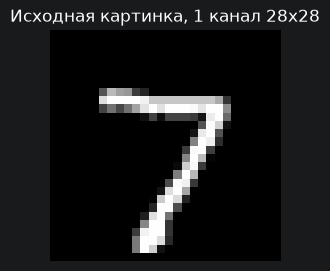

In [16]:
plt.figure(figsize=(3, 3))
plt.imshow(img[0, 0], cmap="gray")
plt.title("Исходная картинка, 1 канал 28x28")
plt.axis("off")
plt.show()

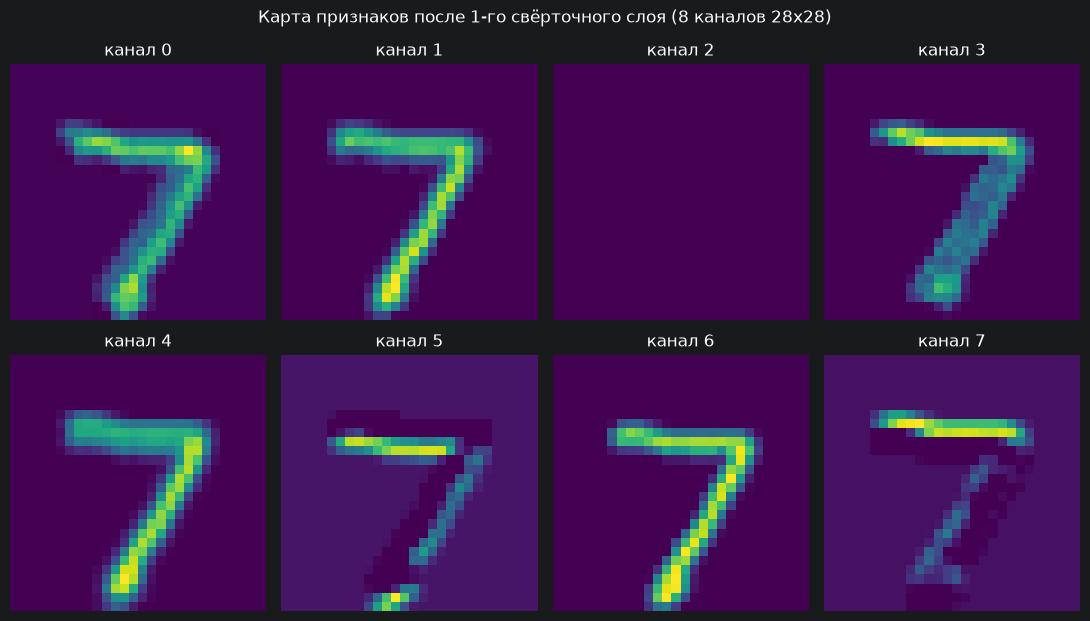

In [17]:
fm1 = outs[1][0].numpy()        # (8, 28, 28) — выход первого свёрточного слоя

fig, axes = plt.subplots(2, 4, figsize=(11, 6.5))

for k, ax in enumerate(axes.flatten()):
    ax.imshow(fm1[k], cmap="viridis")
    ax.set_title("канал " + str(k))
    ax.axis("off")

fig.suptitle("Карта признаков после 1-го свёрточного слоя (8 каналов 28x28)")
plt.tight_layout()
plt.show()

Каждый канал — это исходная картинка, свёрнутая со своим фильтром 3x3, то есть 8 разных
преобразованных представлений одной и той же семёрки. Цифра ещё хорошо узнаётся, но фильтры уже
подсвечивают разные её части: в каналах 3, 5 и 7 ярче всего горизонтальная перекладина, в каналах 0 и 4 —
весь контур целиком, а канал 2 полностью погас (после ReLU там нули) — этот фильтр на такую картинку
не реагирует вообще.

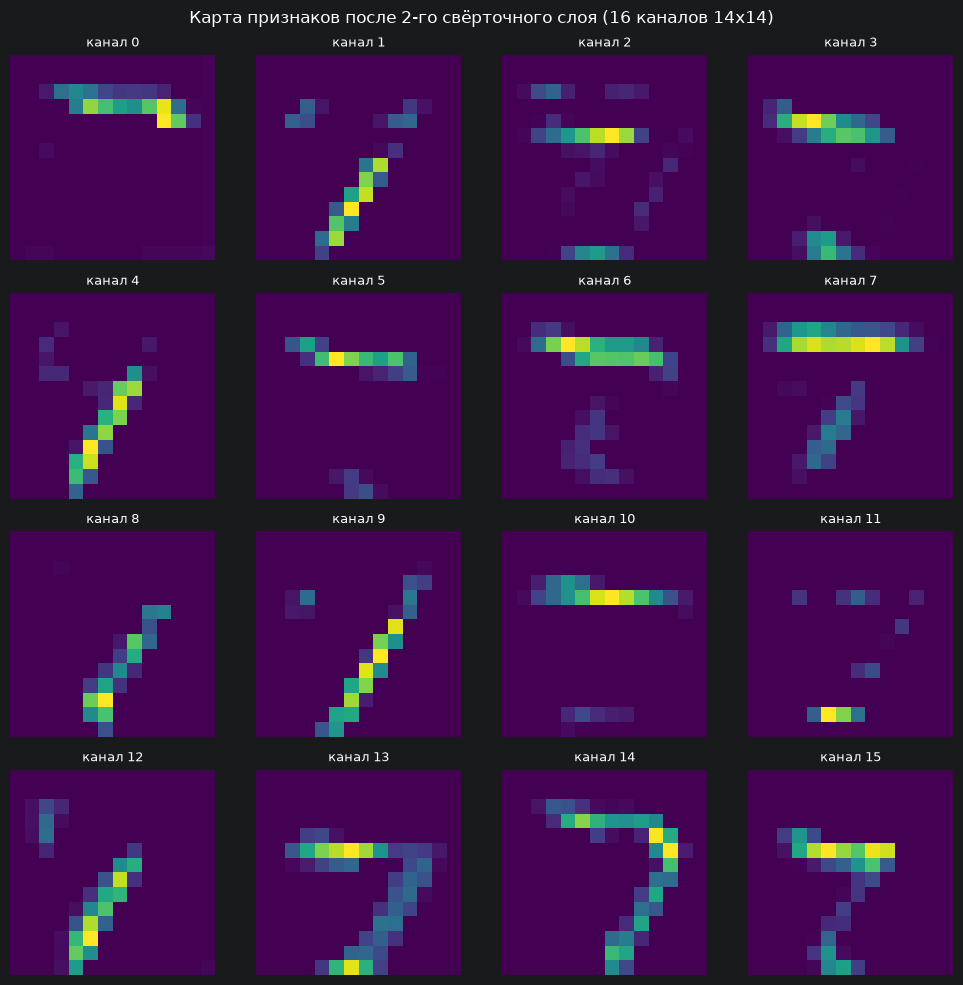

In [18]:
fm2 = outs[4][0].numpy()        # (16, 14, 14) — выход второго свёрточного слоя

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for k, ax in enumerate(axes.flatten()):
    ax.imshow(fm2[k], cmap="viridis")
    ax.set_title("канал " + str(k), fontsize=9)
    ax.axis("off")

fig.suptitle("Карта признаков после 2-го свёрточного слоя (16 каналов 14x14)")
plt.tight_layout()
plt.show()

После второго слоя картинка вдвое меньше и от самой цифры остаётся уже мало: каналы реагируют
на отдельные элементы формы, а не на цифру целиком. Хорошо видно разделение — в каналах 0, 3, 5, 6, 10
подсвечена в основном горизонтальная палочка семёрки, а в каналах 1, 4, 8, 9, 12 — только наклонная,
причём в разных каналах ярче разные её куски (целиком цифра осталась видна лишь в каналах 13-15). Это и есть смысл свёрточной части: сеть постепенно
превращает картинку из набора пикселей в набор признаков «где какой элемент штриха находится»,
и уже по ним полносвязная часть решает, что это за цифра.

## Выводы

- Свёрточная сеть на MNIST работает заметно лучше полносвязной из задания 10: Accuracy 0.9885 против
  0.9787, число ошибок на тестовой выборке упало со 213 до 115. При этом параметров у неё в два раза
  меньше — выигрыш даёт не размер модели, а то, что свёртка обрабатывает пиксели окнами 3x3
  и учитывает их взаимное расположение.
- Две заданные архитектуры оказались практически равными (0.9885 у сети с двумя свёртками против
  0.9878 у сети с тремя). Третья пара conv + pool на картинках 28x28 уже избыточна: после неё
  остаётся карта 3x3, где пространственной информации почти нет. Для MNIST хватает двух свёрток.
- Из двух типов pooling лучше себя показал Max (0.9833 против 0.9785 после трёх эпох): максимум
  по окну сохраняет самый сильный отклик фильтра, а среднее размывает тонкий штрих цифры.
  Число каналов (8 -> 16 -> 32) назначено вручную, без GridSearch.
- Визуализация карт признаков показывает, как работает свёрточная часть: после первого слоя это
  8 вариантов исходной картинки, подсвечивающих разные части контура (один фильтр вообще не
  сработал), а после второго — 16 карт вдвое меньшего размера, где горизонтальные и наклонные
  элементы штриха разошлись по разным каналам.